# Triple Cointegration: XOM / CVX / COP

## Why this triple?

ExxonMobil (XOM), Chevron (CVX), and ConocoPhillips (COP) are the three largest
US integrated oil & gas companies. They share a single dominant fundamental driver:
the WTI crude oil price. Because all three convert the same underlying commodity into
earnings using similar refining and upstream margins, their log-prices should be
pulled by a common stochastic trend — exactly the condition that produces a
cointegrating vector in the Johansen sense.

In the Johansen framework with 3 variables we test for the **rank** of the
cointegration space. We expect rank = 1 or 2:
- **Rank 1**: one long-run relationship (e.g. the oil-price anchor); the three stocks
  share two common stochastic trends.
- **Rank 2**: two independent long-run relationships; only one common trend.

Either case supports a spread trade. The cointegrating vector
$\mathbf{v} = (v_1, v_2, v_3)$ gives the spread
$$\xi_t = v_1 \log X_t + v_2 \log C_t + v_3 \log P_t$$
which we verify to be stationary below.

In [1]:
import sys
sys.path.append("../")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib widget

from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.tsa.stattools import adfuller, kpss

# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv("../../data/real_triple_XOM_CVX_COP.csv", index_col=0)
prices = df[["XOM", "CVX", "COP"]].to_numpy(dtype=np.float64)  # (T, 3)
log_p  = np.log(prices)
T      = len(prices)

q1 = T // 4
q4 = 3 * T // 4

print(f"Total rows  : {T}")
print(f"Train window: 0 – {q4}  ({q4} steps, Q1-Q3)")
print(f"Test window : {q4} – {T}  ({T - q4} steps, Q4)")
print(f"\nFirst prices (XOM, CVX, COP): {prices[0]}")
print(f"Last  prices (XOM, CVX, COP): {prices[-1]}")

Total rows  : 5030
Train window: 0 – 3772  (3772 steps, Q1-Q3)
Test window : 3772 – 5030  (1258 steps, Q4)

First prices (XOM, CVX, COP): [30.32940102 27.47494125 24.33679581]
Last  prices (XOM, CVX, COP): [149.55999756 187.55000305 116.87000275]


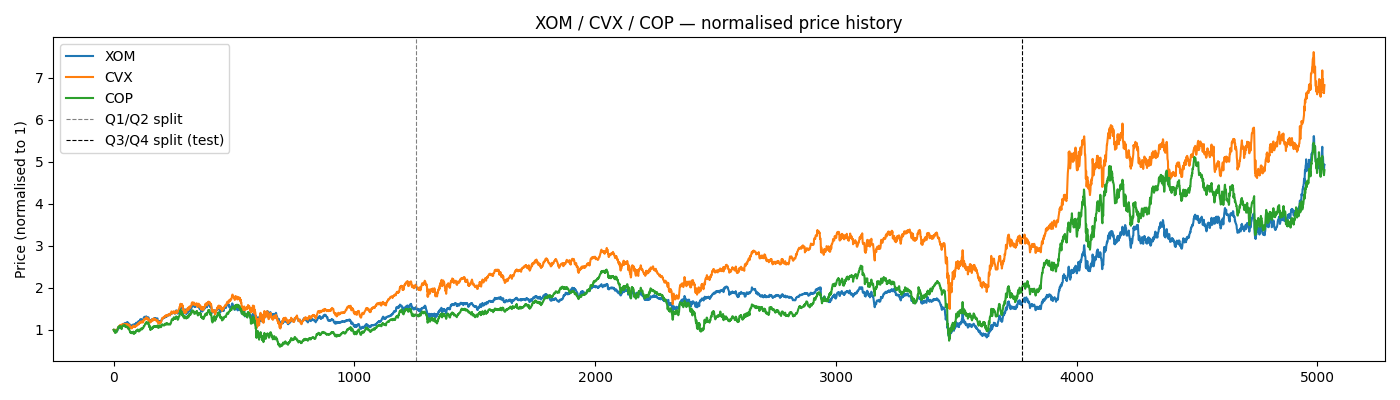

In [2]:
# ── Price history ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
for i, name in enumerate(["XOM", "CVX", "COP"]):
    ax.plot(prices[:, i] / prices[0, i], label=name)  # normalise to 1
ax.axvline(q1, color="gray", linestyle="--", linewidth=0.8, label="Q1/Q2 split")
ax.axvline(q4, color="black", linestyle="--", linewidth=0.8, label="Q3/Q4 split (test)")
ax.set_title("XOM / CVX / COP — normalised price history")
ax.set_ylabel("Price (normalised to 1)")
ax.legend()
plt.tight_layout()
plt.show()

In [3]:
# ── Johansen cointegration test on Q1 calibration window ──────────────────────
log_train = log_p[:q1]   # shape (q1, 3)

jres = coint_johansen(log_train, det_order=0, k_ar_diff=1)

print("Trace statistic test (H0: rank <= r)")
print(f"  {'r=0':>6}  stat={jres.lr1[0]:.3f}  cv_90={jres.cvt[0,0]:.3f}  cv_95={jres.cvt[0,1]:.3f}  cv_99={jres.cvt[0,2]:.3f}")
print(f"  {'r<=1':>6}  stat={jres.lr1[1]:.3f}  cv_90={jres.cvt[1,0]:.3f}  cv_95={jres.cvt[1,1]:.3f}  cv_99={jres.cvt[1,2]:.3f}")
print(f"  {'r<=2':>6}  stat={jres.lr1[2]:.3f}  cv_90={jres.cvt[2,0]:.3f}  cv_95={jres.cvt[2,1]:.3f}  cv_99={jres.cvt[2,2]:.3f}")

print("\nMax-eigenvalue test (H0: rank = r vs r+1)")
print(f"  {'r=0':>6}  stat={jres.lr2[0]:.3f}  cv_90={jres.cvm[0,0]:.3f}  cv_95={jres.cvm[0,1]:.3f}  cv_99={jres.cvm[0,2]:.3f}")
print(f"  {'r<=1':>6}  stat={jres.lr2[1]:.3f}  cv_90={jres.cvm[1,0]:.3f}  cv_95={jres.cvm[1,1]:.3f}  cv_99={jres.cvm[1,2]:.3f}")

print("\nCointegrating eigenvectors (columns):")
print(jres.evec)

# Use the first (strongest) cointegrating vector
cv       = jres.evec[:, 0]
print(f"\nFirst cointegrating vector: XOM={cv[0]:.4f}  CVX={cv[1]:.4f}  COP={cv[2]:.4f}")

Trace statistic test (H0: rank <= r)
     r=0  stat=14.823  cv_90=27.067  cv_95=29.796  cv_99=35.463
    r<=1  stat=5.409  cv_90=13.429  cv_95=15.494  cv_99=19.935
    r<=2  stat=2.033  cv_90=2.705  cv_95=3.841  cv_99=6.635

Max-eigenvalue test (H0: rank = r vs r+1)
     r=0  stat=9.414  cv_90=18.893  cv_95=21.131  cv_99=25.865
    r<=1  stat=3.376  cv_90=12.297  cv_95=14.264  cv_99=18.520

Cointegrating eigenvectors (columns):
[[ 9.60651761  5.85420661  6.89960937]
 [ 2.46605065 -7.09867958 -5.61010339]
 [-4.15073604  4.15566669 -3.1577042 ]]

First cointegrating vector: XOM=9.6065  CVX=2.4661  COP=-4.1507


Spread mean (Q1): 30.840848  (demeaned to 0)
Spread std  (Q1): 1.005983


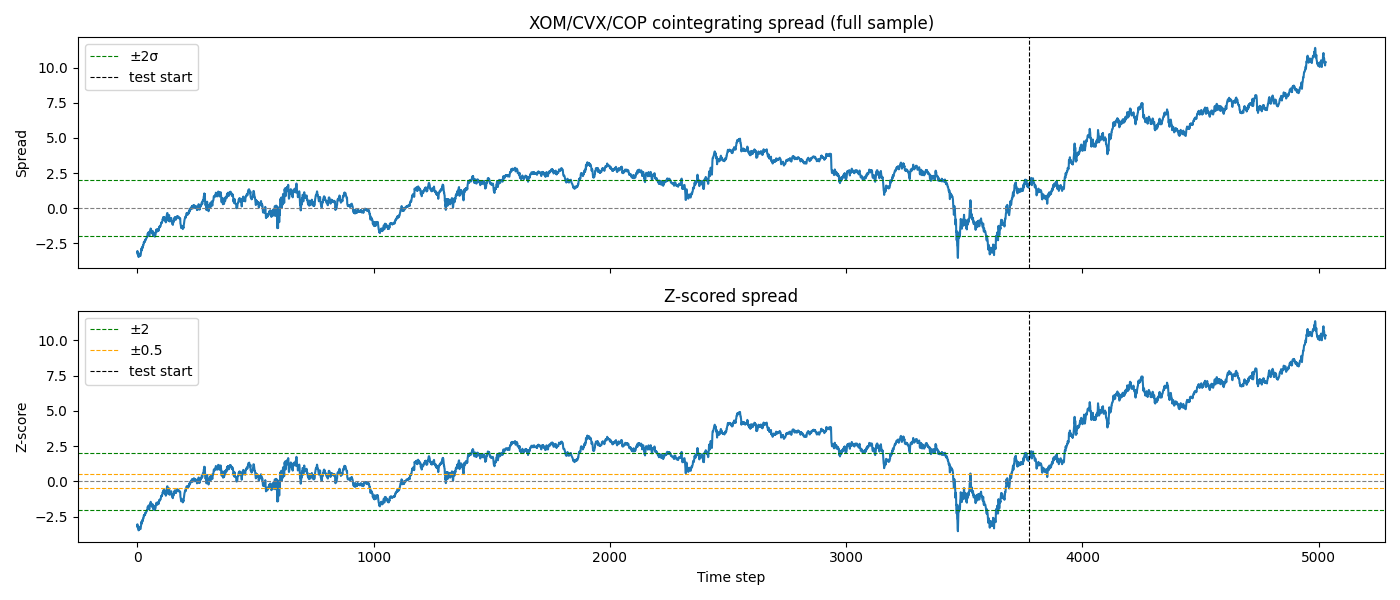

In [4]:
# ── Compute the spread across the full sample ──────────────────────────────────
spread_full = log_p @ cv   # (T,)

# Demean using Q1 estimate
mu        = float(spread_full[:q1].mean())
spread_full -= mu
fixed_std  = float(spread_full[:q1].std())

print(f"Spread mean (Q1): {mu:.6f}  (demeaned to 0)")
print(f"Spread std  (Q1): {fixed_std:.6f}")

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(spread_full)
axes[0].axhline(0,           color="gray",  linewidth=0.8, linestyle="--")
axes[0].axhline( 2*fixed_std, color="green", linewidth=0.8, linestyle="--", label="±2σ")
axes[0].axhline(-2*fixed_std, color="green", linewidth=0.8, linestyle="--")
axes[0].axvline(q4, color="black", linewidth=0.8, linestyle="--", label="test start")
axes[0].set_title("XOM/CVX/COP cointegrating spread (full sample)")
axes[0].set_ylabel("Spread")
axes[0].legend()

axes[1].plot(spread_full / fixed_std)
axes[1].axhline(0,    color="gray",   linewidth=0.8, linestyle="--")
axes[1].axhline( 2.0, color="green",  linewidth=0.8, linestyle="--", label="±2")
axes[1].axhline(-2.0, color="green",  linewidth=0.8, linestyle="--")
axes[1].axhline( 0.5, color="orange", linewidth=0.8, linestyle="--", label="±0.5")
axes[1].axhline(-0.5, color="orange", linewidth=0.8, linestyle="--")
axes[1].axvline(q4, color="black", linewidth=0.8, linestyle="--", label="test start")
axes[1].set_title("Z-scored spread")
axes[1].set_ylabel("Z-score")
axes[1].set_xlabel("Time step")
axes[1].legend()

plt.tight_layout()
plt.show()

In [5]:
# ── Stationarity tests on the spread ──────────────────────────────────────────
spread_train = spread_full[:q1]

adf_stat, adf_p, _, _, adf_cv, _ = adfuller(spread_train, autolag='AIC')
print("ADF test on Q1 spread (H0: unit root)")
print(f"  stat={adf_stat:.4f}  p={adf_p:.4f}  cv_5%={adf_cv['5%']:.4f}")
print(f"  {'REJECT unit root (stationary)' if adf_p < 0.05 else 'FAIL TO REJECT unit root'}")

kpss_stat, kpss_p, _, kpss_cv = kpss(spread_train, regression='c', nlags='auto')
print("\nKPSS test on Q1 spread (H0: stationary)")
print(f"  stat={kpss_stat:.4f}  p={kpss_p:.4f}  cv_5%={kpss_cv['5%']:.4f}")
print(f"  {'FAIL TO REJECT stationarity (stationary)' if kpss_p > 0.05 else 'REJECT stationarity'}")

# AR(1) fit for spread persistence
from statsmodels.tsa.ar_model import AutoReg
ar_fit  = AutoReg(spread_train, lags=1).fit()
phi     = float(ar_fit.params[1])
wn_var  = fixed_std**2 * (1 - phi**2)
half_life = np.log(0.5) / np.log(abs(phi))
print(f"\nAR(1) persistence  phi={phi:.4f}")
print(f"Half-life of mean reversion: {half_life:.1f} trading days")

ADF test on Q1 spread (H0: unit root)
  stat=-3.0501  p=0.0305  cv_5%=-2.8639
  REJECT unit root (stationary)

KPSS test on Q1 spread (H0: stationary)
  stat=1.1772  p=0.0100  cv_5%=0.4630
  REJECT stationarity

AR(1) persistence  phi=0.9852
Half-life of mean reversion: 46.5 trading days


/tmp/ipykernel_34590/3917231525.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, kpss_cv = kpss(spread_train, regression='c', nlags='auto')


In [6]:
# ── Summary of calibrated parameters ──────────────────────────────────────────
print("=" * 50)
print("Calibrated parameters for RL training")
print("=" * 50)
print(f"Cointegrating vector (XOM, CVX, COP):")
print(f"  v = {cv}")
print(f"Spread mean (mu)  : {mu:.6f}")
print(f"Spread std        : {fixed_std:.6f}")
print(f"AR(1) phi         : {phi:.4f}")
print(f"Innovation var    : {wn_var:.8f}")
print(f"Half-life         : {half_life:.1f} days")
print()
print("These parameters are ready to use for DQN training")
print("(extend Market env to support 3-asset spread via dot product with cv).")

Calibrated parameters for RL training
Cointegrating vector (XOM, CVX, COP):
  v = [ 9.60651761  2.46605065 -4.15073604]
Spread mean (mu)  : 30.840848
Spread std        : 1.005983
AR(1) phi         : 0.9852
Innovation var    : 0.02973236
Half-life         : 46.5 days

These parameters are ready to use for DQN training
(extend Market env to support 3-asset spread via dot product with cv).
